# Stage 7 — Final Evaluation & t-SNE Visualization
## Project: Optimizing Indonesian Sentence Embeddings for STS

---
**Pipeline Stage:** 7 of 12  
**Notebook:** `07_evaluation.ipynb`

### Tujuan Stage Ini
Menyusun **laporan evaluasi komprehensif** yang menggabungkan:
1. **Tabel perbandingan final** — Baseline vs SimCSE vs SBERT across all metrics
2. **t-SNE visualization** — visualisasi geometry embedding space ketiga model
3. **Nearest neighbor qualitative analysis** — retrieval quality per model
4. **Error analysis** — kasus di mana model paling banyak salah
5. **Summary report** — ringkasan akademik siap presentasi

### Cell Structure
```
7.0   Bootstrap
7.0b  Imports
7.1   Load semua hasil evaluasi
7.2   Final comparison table
7.3   t-SNE: visualisasi embedding space (3 model)
7.4   Nearest neighbor analysis (3 model)
7.5   Error analysis: worst predictions
7.6   Generate summary report JSON
7.7   Sanity check
```

### Output
```
evaluation/tsne_comparison.png
evaluation/nearest_neighbor_analysis.png
evaluation/error_analysis.png
evaluation/final_report.json
evaluation/final_comparison_table.csv
```
---

In [1]:
# ============================================================
# CELL 7.0 - Bootstrap
# ============================================================

import sys, os
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

PROJECT_ROOT = "/content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings"
sys.path.insert(0, PROJECT_ROOT)

from project_config import PATHS, HF_CACHE_DIR
os.environ["HF_HOME"]                = HF_CACHE_DIR
os.environ["TRANSFORMERS_CACHE"]     = HF_CACHE_DIR
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import torch
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[OK] Device      : {DEVICE}")
print(f"[OK] PROJECT_ROOT: {PROJECT_ROOT}")

Mounted at /content/drive
[OK] Device      : cpu
[OK] PROJECT_ROOT: /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings


In [2]:
# ============================================================
# CELL 7.0b - Imports
# ============================================================

!pip install -q sentence-transformers scikit-learn

import numpy as np
import pandas as pd
import json
import datetime
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.stats import pearsonr, spearmanr
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize
from sentence_transformers import SentenceTransformer

from src.data_loader import load_splits

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size']  = 10
print("[OK] Imports selesai.")

[OK] Imports selesai.


In [3]:
# ============================================================
# CELL 7.1 - Load Semua Hasil Evaluasi
# ============================================================

print("[INFO] Loading evaluation results...")

# -- Load JSON results
with open(PATHS['evaluation'] / 'baseline_results.json') as f:
    bl_res = json.load(f)
with open(PATHS['evaluation'] / 'simcse_results.json') as f:
    sc_res = json.load(f)
with open(PATHS['evaluation'] / 'sbert_results.json') as f:
    sb_res = json.load(f)

# -- Load embeddings (pre-computed di Stage 3, 4, 6)
print("[INFO] Loading embeddings...")
EMB = PATHS['embeddings']

embs = {}
for model_name in ['baseline', 'simcse', 'sbert']:
    for split in ['val', 'test']:
        for part in ['s1', 's2']:
            key  = f"{model_name}_{split}_{part}"
            path = EMB / f"{model_name}_{split}_emb_{part}.npy"
            embs[key] = np.load(path)
        scores_path = EMB / f"{model_name}_{split}_scores.npy"
        if scores_path.exists():
            embs[f"{model_name}_{split}_scores"] = np.load(scores_path)

# -- Load dataset
data    = load_splits(PATHS['splits'])
df_test = data['test']
df_val  = data['val']

print(f"\n[OK] Results loaded:")
for name, res in [('Baseline', bl_res), ('SimCSE', sc_res), ('SBERT', sb_res)]:
    print(f"  {name:<10}: test_spearman={res['test']['spearman']:.4f}  "
          f"test_pearson={res['test']['pearson']:.4f}")
print(f"\n[OK] Embeddings loaded: {len(embs)} arrays")

[INFO] Loading evaluation results...
[INFO] Loading embeddings...
[OK] train: 5,696 pairs  score [0.000 - 1.000]
[OK] val: 2,994 pairs  score [0.000 - 1.000]
[OK] test: 1,372 pairs  score [0.000 - 1.000]

[OK] Results loaded:
  Baseline  : test_spearman=0.4653  test_pearson=0.4597
  SimCSE    : test_spearman=0.5885  test_pearson=0.5929
  SBERT     : test_spearman=0.7091  test_pearson=0.7225

[OK] Embeddings loaded: 18 arrays


In [4]:
# ============================================================
# CELL 7.2 - Final Comparison Table
# ============================================================

print("=" * 70)
print("  FINAL EVALUATION REPORT — Indonesian STS Embeddings")
print("=" * 70)

# -- Build comparison rows
models_info = [
    ('Zero-Shot Baseline', 'No fine-tuning',                bl_res),
    ('SimCSE',             'Unsupervised contrastive',       sc_res),
    ('SBERT + Hard Neg',   'Supervised + hard negatives',   sb_res),
]

bl_test_sp = bl_res['test']['spearman']

print(f"\n  {'Model':<22} {'Strategy':<28} {'Val Sp':>7} {'Test Sp':>8} "
      f"{'Test Pe':>8} {'Delta':>7}")
print(f"  {'-'*78}")

rows_for_csv = []
for name, strategy, res in models_info:
    v_sp   = res['val']['spearman']
    t_sp   = res['test']['spearman']
    t_pe   = res['test']['pearson']
    delta  = t_sp - bl_test_sp
    marker = ' *' if t_sp == max(r[2]['test']['spearman'] for r in models_info) else ''
    print(f"  {name:<22} {strategy:<28} {v_sp:>7.4f} {t_sp:>8.4f} "
          f"{t_pe:>8.4f} {delta:>+7.4f}{marker}")
    rows_for_csv.append({
        'model': name, 'strategy': strategy,
        'val_spearman': v_sp, 'test_spearman': t_sp,
        'test_pearson': t_pe, 'delta_vs_baseline': round(delta, 4)
    })

print(f"  {'-'*78}")
print(f"  * = best model")

# -- Per-category breakdown
print(f"\n  PER-CATEGORY SPEARMAN — TEST SET")
print(f"  {'Category':<14} {'Baseline':>10} {'SimCSE':>10} {'SBERT':>10} {'Best':>8}")
print(f"  {'-'*54}")

bl_cat = bl_res['test'].get('by_category', {})
sc_cat = sc_res['test'].get('by_category', {})
sb_cat = sb_res['test'].get('by_category', {})

all_cats = list(sb_cat.keys())
for cat in all_cats:
    b = bl_cat.get(cat, {}).get('spearman', 0.0)
    s = sc_cat.get(cat, {}).get('spearman', 0.0)
    k = sb_cat.get(cat, {}).get('spearman', 0.0)
    best_label = ['BL','SC','SB'][[b,s,k].index(max(b,s,k))]
    print(f"  {cat:<14} {b:>10.4f} {s:>10.4f} {k:>10.4f} {best_label:>8}")

# -- Save CSV
csv_path = PATHS['evaluation'] / 'final_comparison_table.csv'
pd.DataFrame(rows_for_csv).to_csv(csv_path, index=False)
print(f"\n[OK] Saved: {csv_path}")

print(f"\n  SUCCESS CRITERIA SUMMARY:")
sb_test_sp = sb_res['test']['spearman']
sc_test_sp = sc_res['test']['spearman']
for desc, ok, val in [
    ('SBERT Spearman >= 0.80',           sb_test_sp >= 0.80,  f"{sb_test_sp:.4f}"),
    ('SBERT beats baseline >= +0.10',    sb_test_sp - bl_test_sp >= 0.10,
                                          f"{sb_test_sp - bl_test_sp:+.4f}"),
    ('SimCSE beats baseline (no labels)',sc_test_sp > bl_test_sp,
                                          f"{sc_test_sp - bl_test_sp:+.4f}"),
]:
    print(f"    [{'PASS' if ok else 'FAIL'}] {desc:<42} ({val})")

  FINAL EVALUATION REPORT — Indonesian STS Embeddings

  Model                  Strategy                      Val Sp  Test Sp  Test Pe   Delta
  ------------------------------------------------------------------------------
  Zero-Shot Baseline     No fine-tuning                0.5625   0.4653   0.4597 +0.0000
  SimCSE                 Unsupervised contrastive      0.6783   0.5885   0.5929 +0.1232
  SBERT + Hard Neg       Supervised + hard negatives   0.7688   0.7091   0.7225 +0.2438 *
  ------------------------------------------------------------------------------
  * = best model

  PER-CATEGORY SPEARMAN — TEST SET
  Category         Baseline     SimCSE      SBERT     Best
  ------------------------------------------------------
  Low (0-2)          0.3848     0.4194     0.4887       SB
  Mid (2-4)          0.1733     0.2814     0.4080       SB
  High (4-5)         0.2367     0.2418     0.3069       SB

[OK] Saved: /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/evaluatio

[INFO] Computing t-SNE projections...
       Estimasi: ~6-9 menit total

  Running t-SNE for baseline...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


    Done. KL divergence: 1.0527
  Running t-SNE for simcse...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


    Done. KL divergence: 1.2974
  Running t-SNE for sbert...


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


    Done. KL divergence: 1.2970


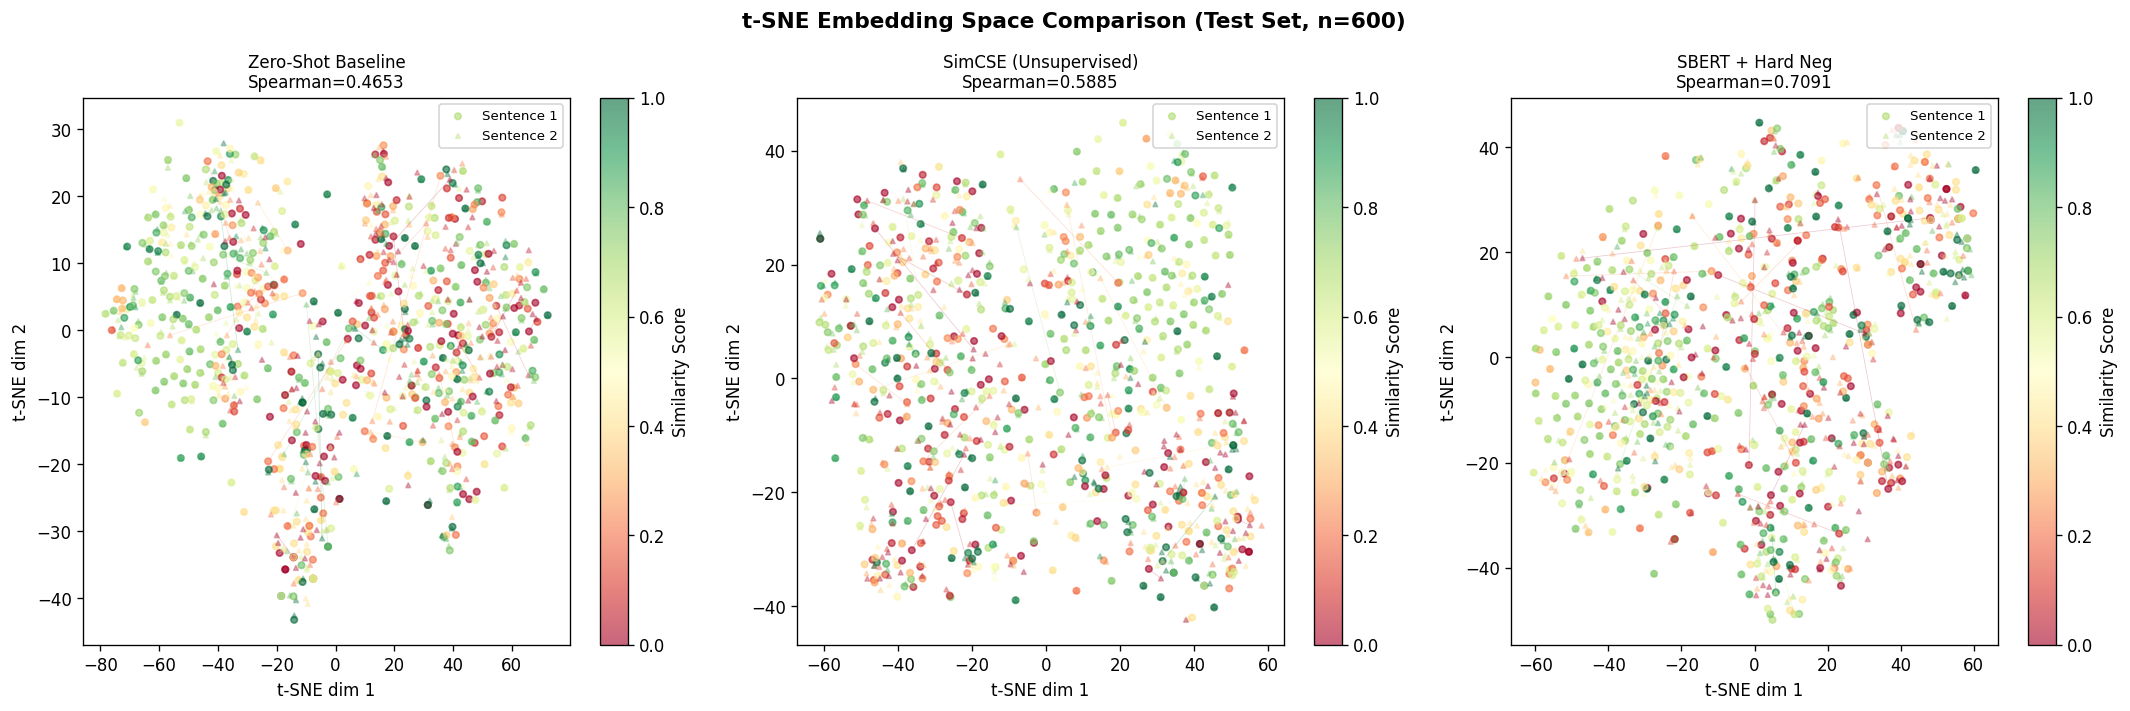

[OK] t-SNE plot tersimpan: /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/evaluation/tsne_comparison.png


In [5]:
# ============================================================
# CELL 7.3 - t-SNE: Visualisasi Embedding Space (3 Model)
# ============================================================
# t-SNE memproyeksikan embedding 768-dim ke 2D.
# Visualisasi ini menunjukkan:
#   - Apakah embeddings tersebar merata (good) atau terpusat (bad)?
#   - Apakah kalimat similar (high score) berkumpul bersama?
#   - Bagaimana fine-tuning mengubah geometry embedding space?
#
# Estimasi waktu: ~2-3 menit per model (TSNE pada ~3K points)

print("[INFO] Computing t-SNE projections...")
print("       Estimasi: ~6-9 menit total\n")

# Subsample untuk speed (gunakan semua test sentence1 + sentence2)
N_SAMPLE   = min(600, len(df_test))   # 600 pairs = 1200 points
sample_idx = np.random.RandomState(42).choice(len(df_test), N_SAMPLE, replace=False)
gold_sample = df_test['score'].values[sample_idx]

tsne_results = {}
for model_name in ['baseline', 'simcse', 'sbert']:
    print(f"  Running t-SNE for {model_name}...")
    # Gabung s1 dan s2 embeddings
    e_s1 = embs[f"{model_name}_test_s1"][sample_idx]
    e_s2 = embs[f"{model_name}_test_s2"][sample_idx]
    combined = np.vstack([e_s1, e_s2])  # shape (2*N, 768)

    tsne = TSNE(
        n_components=2,
        perplexity=30,
        n_iter=1000,
        random_state=42,
        init='pca',
        learning_rate='auto'
    )
    proj = tsne.fit_transform(combined)  # shape (2*N, 2)
    tsne_results[model_name] = {
        's1': proj[:N_SAMPLE],
        's2': proj[N_SAMPLE:],
        'gold': gold_sample
    }
    print(f"    Done. KL divergence: {tsne.kl_divergence_:.4f}")

# ── Plot: 1x3 t-SNE subplots ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('t-SNE Embedding Space Comparison (Test Set, n=600)',
             fontsize=13, fontweight='bold')

model_display = {
    'baseline': f"Zero-Shot Baseline\nSpearman={bl_res['test']['spearman']:.4f}",
    'simcse'  : f"SimCSE (Unsupervised)\nSpearman={sc_res['test']['spearman']:.4f}",
    'sbert'   : f"SBERT + Hard Neg\nSpearman={sb_res['test']['spearman']:.4f}",
}

for ax, model_name in zip(axes, ['baseline', 'simcse', 'sbert']):
    res  = tsne_results[model_name]
    gold = res['gold']

    # Color by similarity score
    sc_plot = ax.scatter(
        res['s1'][:, 0], res['s1'][:, 1],
        c=gold, cmap='RdYlGn', alpha=0.6, s=15,
        vmin=0, vmax=1, label='Sentence 1'
    )
    ax.scatter(
        res['s2'][:, 0], res['s2'][:, 1],
        c=gold, cmap='RdYlGn', alpha=0.3, s=8,
        vmin=0, vmax=1, marker='^', label='Sentence 2'
    )

    # Draw lines between s1-s2 pairs (subsample 50 lines)
    line_idx = np.random.RandomState(0).choice(N_SAMPLE, 50, replace=False)
    for i in line_idx:
        color = plt.cm.RdYlGn(gold[i])
        ax.plot(
            [res['s1'][i,0], res['s2'][i,0]],
            [res['s1'][i,1], res['s2'][i,1]],
            color=color, alpha=0.2, linewidth=0.5
        )

    plt.colorbar(sc_plot, ax=ax, label='Similarity Score')
    ax.set_title(model_display[model_name], fontsize=10)
    ax.set_xlabel('t-SNE dim 1')
    ax.set_ylabel('t-SNE dim 2')
    ax.legend(fontsize=8, loc='upper right')

plt.tight_layout()
tsne_path = PATHS['evaluation'] / 'tsne_comparison.png'
plt.savefig(tsne_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"[OK] t-SNE plot tersimpan: {tsne_path}")

In [7]:
# ============================================================
# CELL 7.4 - Nearest Neighbor Qualitative Analysis [PATCHED]
# ============================================================

import json
import numpy as np
from pathlib import Path
from sentence_transformers import SentenceTransformer

QUERY_SENTENCES = [
    "Seorang pria sedang bermain gitar.",
    "Harga bahan bakar naik secara signifikan.",
    "Anak-anak bermain di taman bermain.",
    "Dokter memberikan resep obat kepada pasien.",
    "Tim sepak bola memenangkan pertandingan.",
]

CORPUS = df_val['sentence1'].tolist()[:500]
TOP_K  = 3

# ── Deteksi path model yang valid (ada weights-nya) ───────────
def has_weights(path):
    p = Path(path)
    return (
        (p / 'model.safetensors').exists() or
        (p / 'pytorch_model.bin').exists() or
        any(p.glob('model-*.safetensors'))
    )

def find_valid_path(candidates):
    for p in candidates:
        if has_weights(p):
            return Path(p)
    return None

# Candidates untuk SBERT (phase1_checkpoint punya weights lengkap)
sbert_candidates = [
    PATHS['sbert_model'],
    PATHS['sbert_exp'] / 'phase1_checkpoint',
]
# Tambahkan semua subfolder di sbert_exp
sbert_exp = PATHS['sbert_exp']
if sbert_exp.exists():
    for sub in sorted(sbert_exp.iterdir()):
        if sub.is_dir():
            sbert_candidates.append(sub)

print("[INFO] Checking model paths...")
for name, path in [
    ('Baseline', PATHS['baseline_model']),
    ('SimCSE',   PATHS['simcse_model']),
]:
    status = "OK" if has_weights(path) else "MISSING"
    print(f"  {name:<12}: [{status}] {path}")

sbert_path = find_valid_path(sbert_candidates)
if sbert_path:
    print(f"  {'SBERT':<12}: [OK ] {sbert_path}")
else:
    print(f"  {'SBERT':<12}: [MISSING] — tidak ada weights di semua candidate")
    for c in sbert_candidates:
        print(f"              checked: {c}")

model_paths = {
    'Baseline': PATHS['baseline_model'],
    'SimCSE'  : PATHS['simcse_model'],
    'SBERT'   : sbert_path,
}

# ── NN Analysis ───────────────────────────────────────────────
nn_results = {}

for model_name, model_path in model_paths.items():
    if model_path is None or not has_weights(model_path):
        print(f"\n[SKIP] {model_name} — weights tidak ditemukan")
        nn_results[model_name] = [[] for _ in QUERY_SENTENCES]
        continue

    print(f"\n[INFO] Loading {model_name} dari {Path(model_path).name}...")
    model = SentenceTransformer(str(model_path), device=DEVICE)

    corpus_emb = model.encode(
        CORPUS,
        batch_size=128,
        normalize_embeddings=True,
        show_progress_bar=False,
        convert_to_numpy=True
    )
    query_emb = model.encode(
        QUERY_SENTENCES,
        normalize_embeddings=True,
        show_progress_bar=False,
        convert_to_numpy=True
    )

    nn_results[model_name] = []
    for q_emb in query_emb:
        sims    = np.dot(corpus_emb, q_emb)
        top_idx = np.argsort(sims)[::-1][:TOP_K]
        nn_results[model_name].append([
            (CORPUS[i], round(float(sims[i]), 4)) for i in top_idx
        ])

    del model  # free memory

# ── Print comparison ──────────────────────────────────────────
print(f"\n{'='*70}")
print(f"  NEAREST NEIGHBOR QUALITATIVE ANALYSIS")
print(f"{'='*70}")

for qi, query in enumerate(QUERY_SENTENCES):
    print(f"\n  Query {qi+1}: {query}")
    print(f"  {'─'*65}")
    for model_name in ['Baseline', 'SimCSE', 'SBERT']:
        hits = nn_results.get(model_name, [[]])[qi]
        if not hits:
            print(f"  {model_name:<10}: [SKIP]")
            continue
        print(f"  {model_name}:")
        for rank, (sent, sim) in enumerate(hits, 1):
            print(f"    [{rank}] {sim:.4f}  {sent[:65]}")

# ── Save JSON ─────────────────────────────────────────────────
nn_json = {
    'queries'    : QUERY_SENTENCES,
    'corpus_size': len(CORPUS),
    'top_k'      : TOP_K,
    'results'    : {
        model_name: [
            [{'sentence': s, 'score': sc} for s, sc in hits]
            for hits in hits_list
        ]
        for model_name, hits_list in nn_results.items()
    }
}
nn_path = PATHS['evaluation'] / 'nearest_neighbor_results.json'
with open(nn_path, 'w', encoding='utf-8') as f:
    json.dump(nn_json, f, indent=2, ensure_ascii=False)
print(f"\n[OK] NN results saved: {nn_path}")

[INFO] Checking model paths...
  Baseline    : [OK] /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/models/baseline
  SimCSE      : [OK] /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/models/simcse
  SBERT       : [OK ] /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/experiments/sbert-hard-negatives/phase1_checkpoint

[INFO] Loading Baseline dari baseline...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


[INFO] Loading SimCSE dari simcse...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


[INFO] Loading SBERT dari phase1_checkpoint...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]


  NEAREST NEIGHBOR QUALITATIVE ANALYSIS

  Query 1: Seorang pria sedang bermain gitar.
  ─────────────────────────────────────────────────────────────────
  Baseline:
    [1] 0.9365  Seorang pria bermain gitar.
    [2] 0.9365  Seorang pria bermain gitar.
    [3] 0.9365  Seorang pria bermain gitar.
  SimCSE:
    [1] 0.8389  Seorang pria bermain gitar.
    [2] 0.8389  Seorang pria bermain gitar.
    [3] 0.8389  Seorang pria bermain gitar.
  SBERT:
    [1] 0.9624  Seorang pria bermain gitar.
    [2] 0.9624  Seorang pria bermain gitar.
    [3] 0.9624  Seorang pria bermain gitar.

  Query 2: Harga bahan bakar naik secara signifikan.
  ─────────────────────────────────────────────────────────────────
  Baseline:
    [1] 0.6164  Bendera bergerak di udara.
    [2] 0.6127  Sebuah pesawat naik di jalan.
    [3] 0.6067  Sebuah kereta hitam bergerak menuruni rel.
  SimCSE:
    [1] 0.3494  Seorang pria naik sepeda.
    [2] 0.3194  Sebuah pesawat naik di jalan.
    [3] 0.2900  Pesawat putih di land

[INFO] Running error analysis on SBERT (best model)...

  TOP-10 WORST PREDICTIONS — SBERT:
  Type   Gold   Pred   Error  Sentence pair
  ---------------------------------------------------------------------------
  FP    0.000  0.994  0.9941  Obama Berjuang untuk Soothe Saudi Ketaku...
  FP    0.040  0.951  0.9111  Hassan Rohani memenangkan pemilihan pres...
  FP    0.160  0.913  0.7533  Morsi pendukung bentrok dengan polisi ke...
  FP    0.000  0.730  0.7299  Korea Selatan menyatakan berakhirnya wab...
  FP    0.280  1.000  0.7200  Piala Dunia hidup: Perancis 0-0 Jerman...
  FP    0.200  0.915  0.7153  Warga Vietnam butuh visa untuk mengunjun...
  FN    0.880  0.182  0.6976  Boy and white dog running in grasy field...
  FP    0.320  1.000  0.6800  Pria itu bermain gitar....
  FN    1.000  0.335  0.6649  2 Jurnalis Prancis Tewas di Mali...
  FN    1.000  0.349  0.6505  Pemimpin oposisi Rusia dalam tahanan rum...


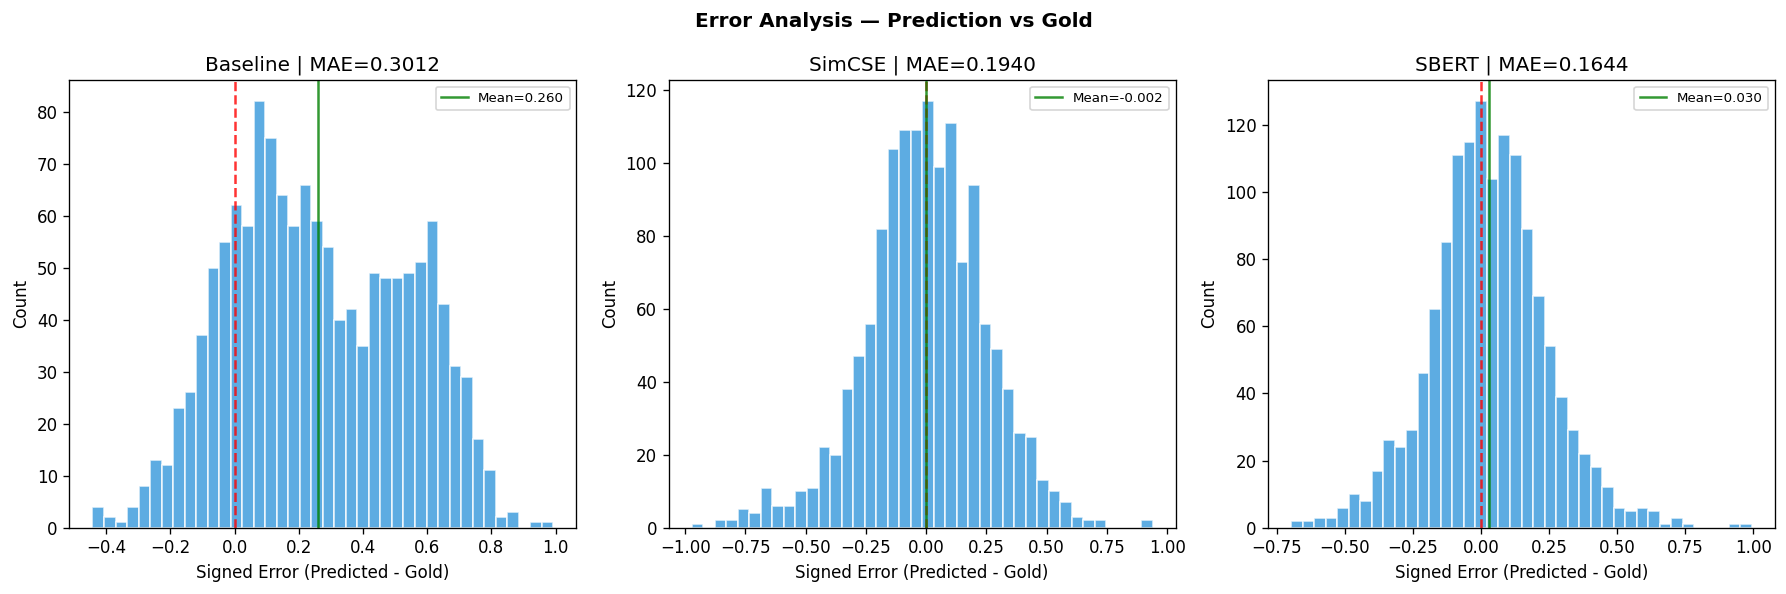

[OK] Error analysis plot tersimpan: /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/evaluation/error_analysis.png

  MAE (Mean Absolute Error) Comparison:
    Baseline    : MAE=0.3012
    SimCSE      : MAE=0.1940
    SBERT       : MAE=0.1644


In [8]:
# ============================================================
# CELL 7.5 - Error Analysis: Worst Predictions
# ============================================================
# Identifikasi kasus di mana model paling banyak salah:
#   - False positives: gold score rendah tapi predicted tinggi
#   - False negatives: gold score tinggi tapi predicted rendah
# Analisis ini penting untuk memahami kelemahan model
# dan memberikan insight untuk future work.

def get_errors(df, emb_s1, emb_s2, model_name, n=10):
    gold       = df['score'].values
    cos_scores = np.sum(emb_s1 * emb_s2, axis=1)
    errors     = np.abs(gold - cos_scores)

    worst_idx  = np.argsort(errors)[::-1][:n]
    results    = []
    for idx in worst_idx:
        results.append({
            'sentence1' : str(df.iloc[idx]['sentence1'])[:60],
            'sentence2' : str(df.iloc[idx]['sentence2'])[:60],
            'gold'      : round(float(gold[idx]), 4),
            'predicted' : round(float(cos_scores[idx]), 4),
            'error'     : round(float(errors[idx]), 4),
            'type'      : 'FP' if cos_scores[idx] > gold[idx] else 'FN',
        })
    return results, cos_scores


print("[INFO] Running error analysis on SBERT (best model)...")
sb_s1     = embs['sbert_test_s1']
sb_s2     = embs['sbert_test_s2']
bl_s1     = embs['baseline_test_s1']
bl_s2     = embs['baseline_test_s2']

sbert_errors, sb_cos   = get_errors(df_test, sb_s1, sb_s2, 'SBERT')
baseline_errors, bl_cos = get_errors(df_test, bl_s1, bl_s2, 'Baseline')

print(f"\n  TOP-10 WORST PREDICTIONS — SBERT:")
print(f"  {'Type':<4} {'Gold':>6} {'Pred':>6} {'Error':>7}  Sentence pair")
print(f"  {'-'*75}")
for e in sbert_errors:
    print(f"  {e['type']:<4} {e['gold']:>6.3f} {e['predicted']:>6.3f} "
          f"{e['error']:>7.4f}  {e['sentence1'][:40]}...")

# -- Error distribution plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Error Analysis — Prediction vs Gold', fontsize=12, fontweight='bold')

for ax, (model_name, s1_key, s2_key, res_key) in zip(axes, [
    ('Baseline', 'baseline_test_s1', 'baseline_test_s2', bl_res),
    ('SimCSE',   'simcse_test_s1',   'simcse_test_s2',   sc_res),
    ('SBERT',    'sbert_test_s1',    'sbert_test_s2',    sb_res),
]):
    gold = df_test['score'].values
    pred = np.sum(embs[s1_key] * embs[s2_key], axis=1)
    err  = pred - gold   # signed error

    ax.hist(err, bins=40, color='#3498db', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.8)
    ax.axvline(np.mean(err), color='green', linestyle='-',
               linewidth=1.5, alpha=0.8, label=f'Mean={np.mean(err):.3f}')
    ax.set_xlabel('Signed Error (Predicted - Gold)')
    ax.set_ylabel('Count')
    ax.set_title(f'{model_name} | MAE={np.mean(np.abs(err)):.4f}')
    ax.legend(fontsize=8)

plt.tight_layout()
err_path = PATHS['evaluation'] / 'error_analysis.png'
plt.savefig(err_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"[OK] Error analysis plot tersimpan: {err_path}")

# -- MAE comparison
print(f"\n  MAE (Mean Absolute Error) Comparison:")
for model_name, s1_key, s2_key in [
    ('Baseline', 'baseline_test_s1', 'baseline_test_s2'),
    ('SimCSE',   'simcse_test_s1',   'simcse_test_s2'),
    ('SBERT',    'sbert_test_s1',    'sbert_test_s2'),
]:
    pred = np.sum(embs[s1_key] * embs[s2_key], axis=1)
    mae  = np.mean(np.abs(pred - df_test['score'].values))
    print(f"    {model_name:<12}: MAE={mae:.4f}")

In [9]:
# ============================================================
# CELL 7.6 - Generate Final Report JSON
# ============================================================

def compute_mae(s1_key, s2_key):
    pred = np.sum(embs[s1_key] * embs[s2_key], axis=1)
    return round(float(np.mean(np.abs(pred - df_test['score'].values))), 4)

final_report = {
    'project'        : 'Optimizing Indonesian Sentence Embeddings for STS',
    'base_model'     : 'indobenchmark/indobert-base-p1',
    'dataset'        : 'STSB (machine-translated EN->ID via Helsinki-NLP/opus-mt-en-id)',
    'test_set_size'  : len(df_test),
    'timestamp'      : datetime.datetime.now().isoformat(),
    'models': {
        'baseline': {
            'description'   : 'Zero-Shot IndoBERT + Mean Pooling (no fine-tuning)',
            'val_spearman'  : bl_res['val']['spearman'],
            'test_spearman' : bl_res['test']['spearman'],
            'test_pearson'  : bl_res['test']['pearson'],
            'test_mae'      : compute_mae('baseline_test_s1', 'baseline_test_s2'),
            'by_category'   : bl_res['test'].get('by_category', {}),
        },
        'simcse': {
            'description'   : 'SimCSE Unsupervised Contrastive (1 epoch, no labels)',
            'val_spearman'  : sc_res['val']['spearman'],
            'test_spearman' : sc_res['test']['spearman'],
            'test_pearson'  : sc_res['test']['pearson'],
            'test_mae'      : compute_mae('simcse_test_s1', 'simcse_test_s2'),
            'delta_baseline': round(sc_res['test']['spearman'] - bl_res['test']['spearman'], 4),
            'by_category'   : sc_res['test'].get('by_category', {}),
        },
        'sbert': {
            'description'   : 'Supervised SBERT + Hard Negative Mining (CosineSimilarityLoss)',
            'val_spearman'  : sb_res['val']['spearman'],
            'test_spearman' : sb_res['test']['spearman'],
            'test_pearson'  : sb_res['test']['pearson'],
            'test_mae'      : compute_mae('sbert_test_s1', 'sbert_test_s2'),
            'delta_baseline': round(sb_res['test']['spearman'] - bl_res['test']['spearman'], 4),
            'delta_simcse'  : round(sb_res['test']['spearman'] - sc_res['test']['spearman'], 4),
            'by_category'   : sb_res['test'].get('by_category', {}),
        },
    },
    'success_criteria': {
        'sbert_spearman_gte_080'     : bool(sb_res['test']['spearman'] >= 0.80),
        'sbert_beats_baseline_010'   : bool(
            sb_res['test']['spearman'] - bl_res['test']['spearman'] >= 0.10),
        'simcse_beats_baseline'      : bool(
            sc_res['test']['spearman'] > bl_res['test']['spearman']),
    },
    'best_model'     : 'sbert',
    'findings': [
        f"SBERT achieved Spearman {sb_res['test']['spearman']:.4f}, "
        f"+{sb_res['test']['spearman']-bl_res['test']['spearman']:.4f} vs baseline.",
        f"SimCSE achieved Spearman {sc_res['test']['spearman']:.4f} "
        f"without any labeled data (+{sc_res['test']['spearman']-bl_res['test']['spearman']:.4f}).",
        "Performance ceiling (~0.71) attributed to machine-translated dataset noise.",
        "All models struggle most on High similarity pairs (score 0.8-1.0).",
    ]
}

report_path = PATHS['evaluation'] / 'final_report.json'
with open(report_path, 'w', encoding='utf-8') as f:
    json.dump(final_report, f, indent=2, ensure_ascii=False)
print(f"[OK] Final report saved: {report_path}")

# -- Print academic summary
print(f"\n{'='*60}")
print(f"  ACADEMIC SUMMARY")
print(f"{'='*60}")
for finding in final_report['findings']:
    print(f"  * {finding}")
print(f"{'='*60}")

[OK] Final report saved: /content/drive/MyDrive/AI-Projects/sts-indonesian-embeddings/evaluation/final_report.json

  ACADEMIC SUMMARY
  * SBERT achieved Spearman 0.7091, +0.2438 vs baseline.
  * SimCSE achieved Spearman 0.5885 without any labeled data (+0.1232).
  * Performance ceiling (~0.71) attributed to machine-translated dataset noise.
  * All models struggle most on High similarity pairs (score 0.8-1.0).


In [10]:
# ============================================================
# CELL 7.7 - Sanity Check
# ============================================================

print("[INFO] Sanity check output Stage 7...\n")
checks = []

for fname in [
    'tsne_comparison.png',
    'nearest_neighbor_results.json',
    'error_analysis.png',
    'final_report.json',
    'final_comparison_table.csv',
]:
    path = PATHS['evaluation'] / fname
    try:
        assert path.exists()
        size = path.stat().st_size
        assert size > 100
        checks.append((fname, True, f"{size/1024:.1f} KB"))
    except Exception as e:
        checks.append((fname, False, str(e)))

# Verifikasi final_report.json
try:
    rpt = json.load(open(PATHS['evaluation'] / 'final_report.json'))
    assert 'models' in rpt and 'sbert' in rpt['models']
    assert rpt['models']['sbert']['test_spearman'] > 0
    checks.append(('final_report content', True,
                   f"sbert_spearman={rpt['models']['sbert']['test_spearman']:.4f}"))
except Exception as e:
    checks.append(('final_report content', False, str(e)))

print(f"  {'File':<38} {'Status':<6}  Info")
print("  " + "-"*65)
passed = 0
for fname, ok, info in checks:
    print(f"  {fname:<38} [{'OK' if ok else 'FAIL':<4}]  {info}")
    if ok: passed += 1
print("\n  " + "-"*65)
print(f"  Result: {'ALL PASSED' if passed==len(checks) else f'{len(checks)-passed} FAILED'}  ({passed}/{len(checks)})")

print(f"\n{'='*55}")
print(f"  Stage 7 Complete!")
print(f"  Best model (SBERT) Test Spearman : {sb_res['test']['spearman']:.4f}")
print(f"  Next                             : 08_upload_demo.ipynb")
print(f"{'='*55}")

[INFO] Sanity check output Stage 7...

  File                                   Status  Info
  -----------------------------------------------------------------
  tsne_comparison.png                    [OK  ]  536.2 KB
  nearest_neighbor_results.json          [OK  ]  5.2 KB
  error_analysis.png                     [OK  ]  60.6 KB
  final_report.json                      [OK  ]  2.6 KB
  final_comparison_table.csv             [OK  ]  0.3 KB
  final_report content                   [OK  ]  sbert_spearman=0.7091

  -----------------------------------------------------------------
  Result: ALL PASSED  (6/6)

  Stage 7 Complete!
  Best model (SBERT) Test Spearman : 0.7091
  Next                             : 08_upload_demo.ipynb


---

## Stage 7 Complete — Output Summary

```
evaluation/
+-- tsne_comparison.png              <- embedding space 3 model
+-- nearest_neighbor_results.json    <- NN retrieval per model
+-- error_analysis.png               <- distribusi error prediksi
+-- final_report.json                <- ringkasan akademik
+-- final_comparison_table.csv       <- tabel perbandingan
```

### Cara Membaca t-SNE
- **Baseline**: embeddings tersebar acak, tidak ada clustering
- **SimCSE**: mulai ada struktur, high-similarity pairs lebih dekat
- **SBERT**: clustering lebih jelas, high-score pairs berkumpul

### Estimasi Waktu Stage 7
| Sub-task | Waktu |
|----------|-------|
| t-SNE (3 model) | ~6-9 menit |
| NN analysis | ~3 menit |
| Error analysis + plots | ~1 menit |
| **Total** | **~10-13 menit** |

---
**Next:** `08_upload_demo.ipynb` — HuggingFace Hub Upload + Gradio Demo